In [ ]:
import os
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils import class_weight

IMG_SIZE = 48 
BATCH_SIZE = 64 
dataset_path = r"C:\Users\User\.cache\kagglehub\datasets\msambare\fer2013\versions\1"

def apply_clahe(img):

    img = (img * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img)
    return img_clahe.reshape(IMG_SIZE, IMG_SIZE, 1) / 255.0

train_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe, 
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='reflect'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(dataset_path, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)


classes = train_generator.classes 
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)
class_weight_dict = dict(enumerate(weights))

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def build_ultimate_vision_model():
    model = models.Sequential([
        
        layers.Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

    
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),


        layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(7, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model

In [ ]:


checkpoint = ModelCheckpoint(
    'ZenithView_CustomCNN_Best_17.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=5, 
    min_lr=1e-7, 
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)

print("🚀 Launching Final Vision Training for ZenithView...")
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

🚀 Launching Final Vision Training for ZenithView...
Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.1697 - loss: 9.0700
Epoch 1: val_accuracy improved from None to 0.13165, saving model to ZenithView_CustomCNN_Best_17.keras

Epoch 1: finished saving model to ZenithView_CustomCNN_Best_17.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 344s 749ms/step - accuracy: 0.1876 - loss: 6.5081 - val_accuracy: 0.1317 - val_loss: 3.3362 - learning_rate: 0.0010
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.2316 - loss: 3.0579
Epoch 2: val_accuracy improved from 0.13165 to 0.37852, saving model to ZenithView_CustomCNN_Best_17.keras

Epoch 2: finished saving model to ZenithView_CustomCNN_Best_17.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 331s 737ms/step - accuracy: 0.2431 - loss: 2.8895 - val_accuracy: 0.3785 - val_loss: 2.4552 - learning_rate: 0.0010
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.2778 - loss: 2.5703
Epoch 3: val_accuracy did not improve from 

In [3]:
from tensorflow.keras.models import load_model
model=load_model('ZenithView_CustomCNN_Best_17.keras')

In [7]:

checkpoint = ModelCheckpoint(
    'ZenithView_CustomCNN_Best_17.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-7, 
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)
model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=50,
     initial_epoch=30,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Epoch 31/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.5605 - loss: 1.4408
Epoch 31: val_accuracy improved from None to 0.58693, saving model to ZenithView_CustomCNN_Best_17.keras

Epoch 31: finished saving model to ZenithView_CustomCNN_Best_17.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 330s 718ms/step - accuracy: 0.5555 - loss: 1.4329 - val_accuracy: 0.5869 - val_loss: 1.3741 - learning_rate: 1.0000e-04
Epoch 32/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.5535 - loss: 1.4224
Epoch 32: val_accuracy did not improve from 0.58693
449/449 ━━━━━━━━━━━━━━━━━━━━ 333s 742ms/step - accuracy: 0.5532 - loss: 1.4279 - val_accuracy: 0.5816 - val_loss: 1.3841 - learning_rate: 1.0000e-04
Epoch 33/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5580 - loss: 1.4200
Epoch 33: val_accuracy did not improve from 0.58693
449/449 ━━━━━━━━━━━━━━━━━━━━ 525s 1s/step - accuracy: 0.5550 - loss: 1.4260 - val_accuracy: 0.5809 - val_loss: 1.3855 - learning_rate: 1.0000e-04
Epoch 34/50


In [5]:
checkpoint = ModelCheckpoint(
    'ZenithView_CustomCNN_Best_17.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,      # Gentler drop to find the peak
    patience=5,      # Give it more time to improve
    min_lr=1e-7, 
    verbose=1
)

# 2. Use a slightly different Optimizer setting
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), # Start even lower for Phase 3
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15), # Increase smoothing to handle dataset noise
    metrics=['accuracy']
)

# 3. Resume with more epochs
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=70,         # Set a higher target
    initial_epoch=50,   # Start from where you left off
    class_weight=class_weight_dict,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Epoch 51/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.5670 - loss: 1.4370
Epoch 51: val_accuracy improved from None to 0.60003, saving model to ZenithView_CustomCNN_Best_17.keras

Epoch 51: finished saving model to ZenithView_CustomCNN_Best_17.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 310s 674ms/step - accuracy: 0.5689 - loss: 1.4281 - val_accuracy: 0.6000 - val_loss: 1.3886 - learning_rate: 5.0000e-05
Epoch 52/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.5682 - loss: 1.4239
Epoch 52: val_accuracy did not improve from 0.60003
449/449 ━━━━━━━━━━━━━━━━━━━━ 312s 695ms/step - accuracy: 0.5669 - loss: 1.4309 - val_accuracy: 0.5968 - val_loss: 1.4071 - learning_rate: 5.0000e-05
Epoch 53/70
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.5709 - loss: 1.4133
Epoch 53: val_accuracy did not improve from 0.60003
449/449 ━━━━━━━━━━━━━━━━━━━━ 312s 694ms/step - accuracy: 0.5718 - loss: 1.4305 - val_accuracy: 0.5950 - val_loss: 1.4009 - learning_rate: 5.0000e-05
Epoch 

KeyboardInterrupt: 

In [4]:
from tensorflow.keras.models import load_model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model = load_model('ZenithView_CustomCNN_Best.keras')
print("✅ Progress Restored: Starting back at 63.84% accuracy!")

history_resume = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=50,
    initial_epoch=40, 
    class_weight=class_weight_dict,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

✅ Progress Restored: Starting back at 63.84% accuracy!
Epoch 41/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.6180 - loss: 1.1862
Epoch 41: val_accuracy improved from None to 0.63486, saving model to ZenithView_CustomCNN_Best.keras

Epoch 41: finished saving model to ZenithView_CustomCNN_Best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 305s 665ms/step - accuracy: 0.6166 - loss: 1.1919 - val_accuracy: 0.6349 - val_loss: 1.2136 - learning_rate: 4.0000e-05
Epoch 42/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.6132 - loss: 1.2018
Epoch 42: val_accuracy improved from 0.63486 to 0.63555, saving model to ZenithView_CustomCNN_Best.keras

Epoch 42: finished saving model to ZenithView_CustomCNN_Best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 315s 702ms/step - accuracy: 0.6176 - loss: 1.1939 - val_accuracy: 0.6356 - val_loss: 1.2139 - learning_rate: 4.0000e-05
Epoch 43/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.6145 - loss: 1.1879
Epoch 43: val_accuracy improved from 

In [5]:
model.save('ZenithView_CustomCNN_Best.keras')

In [4]:
from tensorflow.keras.models import load_model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model = load_model('ZenithView_CustomCNN_Best.keras')
from tensorflow.keras.optimizers import SGD
model.compile(
    optimizer=SGD(learning_rate=0.0001, momentum=0.9, nesterov=True),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history_70_push = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=60,            # The "end line" for this run
    initial_epoch=50,     # The "starting line" (where we left off)
    class_weight=class_weight_dict,
    callbacks=[checkpoint]
)

Epoch 51/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.6147 - loss: 1.1960
Epoch 51: val_accuracy improved from None to 0.63179, saving model to ZenithView_CustomCNN_Best.keras

Epoch 51: finished saving model to ZenithView_CustomCNN_Best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 270s 591ms/step - accuracy: 0.6156 - loss: 1.1901 - val_accuracy: 0.6318 - val_loss: 1.2178
Epoch 52/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.6152 - loss: 1.1914
Epoch 52: val_accuracy improved from 0.63179 to 0.63750, saving model to ZenithView_CustomCNN_Best.keras

Epoch 52: finished saving model to ZenithView_CustomCNN_Best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 271s 604ms/step - accuracy: 0.6172 - loss: 1.1918 - val_accuracy: 0.6375 - val_loss: 1.2092
Epoch 53/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.6251 - loss: 1.1792
Epoch 53: val_accuracy improved from 0.63750 to 0.63792, saving model to ZenithView_CustomCNN_Best.keras

Epoch 53: finished saving model to ZenithV

In [ ]:
from tensorflow.keras.models import load_model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model = load_model('ZenithView_CustomCNN_Best.keras', compile=False)
print("✅ Weights loaded. Now carefully re-initializing...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history_70_push = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=80,
    initial_epoch=60,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

✅ Weights loaded. Now carefully re-initializing...
Epoch 61/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.6218 - loss: 1.1881
Epoch 61: val_accuracy improved from None to 0.63681, saving model to ZenithView_CustomCNN_Best.keras

Epoch 61: finished saving model to ZenithView_CustomCNN_Best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 287s 624ms/step - accuracy: 0.6224 - loss: 1.1863 - val_accuracy: 0.6368 - val_loss: 1.2076 - learning_rate: 5.0000e-05
Epoch 62/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.6244 - loss: 1.1910
Epoch 62: val_accuracy improved from 0.63681 to 0.64224, saving model to ZenithView_CustomCNN_Best.keras

Epoch 62: finished saving model to ZenithView_CustomCNN_Best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 288s 642ms/step - accuracy: 0.6264 - loss: 1.1757 - val_accuracy: 0.6422 - val_loss: 1.2058 - learning_rate: 5.0000e-05
Epoch 63/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.6215 - loss: 1.1790
Epoch 63: val_accuracy did not improve fr

KeyboardInterrupt: 

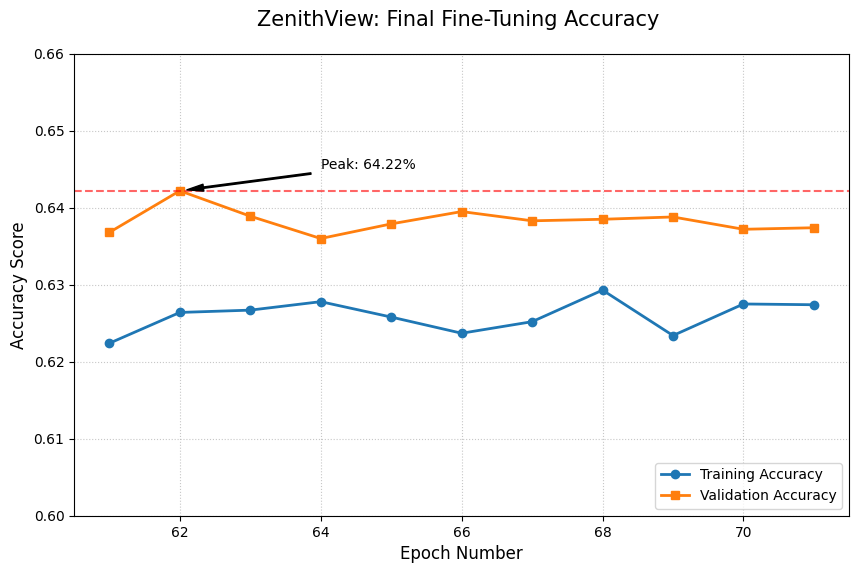

In [ ]:
import matplotlib.pyplot as plt

# 1. Data extracted from your successful logs (Epoch 61 to 71)
epochs = [61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]
train_acc = [0.6224, 0.6264, 0.6267, 0.6278, 0.6258, 0.6237, 0.6252, 0.6293, 0.6234, 0.6275, 0.6274]
val_acc = [0.6368, 0.6422, 0.6389, 0.6360, 0.6379, 0.6395, 0.6383, 0.6385, 0.6388, 0.6372, 0.6374]


plt.figure(figsize=(10, 6))
plt.plot(epochs, train_acc, color='#1f77b4', marker='o', linestyle='-', linewidth=2, label='Training Accuracy')
plt.plot(epochs, val_acc, color='#ff7f0e', marker='s', linestyle='-', linewidth=2, label='Validation Accuracy')

# Highlight the Peak
plt.axhline(y=0.6422, color='red', linestyle='--', alpha=0.6)
plt.annotate(f'Peak: 64.22%', xy=(62, 0.6422), xytext=(64, 0.645),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.title('ZenithView: Final Fine-Tuning Accuracy ', fontsize=15, pad=20)
plt.xlabel('Epoch Number', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.60, 0.66) # Zooming in on the 60s to show detail
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right')

plt.savefig('ZenithView_Final_Accuracy.png', dpi=300)
plt.show()


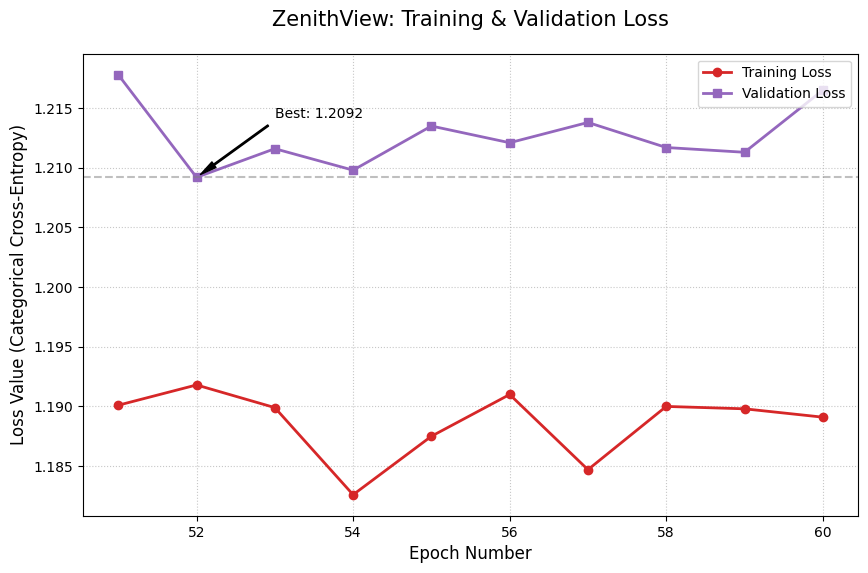

In [ ]:
import matplotlib.pyplot as plt

# 1. Data extracted from your fine-tuning logs (Epoch 51 to 60)
# These represent your most recent training run where the model stabilized
epochs = range(51, 61)
train_loss = [1.1901, 1.1918, 1.1899, 1.1826, 1.1875, 1.1910, 1.1847, 1.1900, 1.1898, 1.1891]
val_loss = [1.2178, 1.2092, 1.2116, 1.2098, 1.2135, 1.2121, 1.2138, 1.2117, 1.2113, 1.2165]

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_loss, color='#d62728', marker='o', linestyle='-', linewidth=2, label='Training Loss')
plt.plot(epochs, val_loss, color='#9467bd', marker='s', linestyle='-', linewidth=2, label='Validation Loss')

# Highlight the Minimum (Best model checkpoint usually happens at lowest val_loss)
min_val_loss = min(val_loss)
min_epoch = epochs[val_loss.index(min_val_loss)]
plt.axhline(y=min_val_loss, color='gray', linestyle='--', alpha=0.5)
plt.annotate(f'Best: {min_val_loss:.4f}', xy=(min_epoch, min_val_loss), xytext=(min_epoch+1, min_val_loss+0.005),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.title('ZenithView: Training & Validation Loss', fontsize=15, pad=20)
plt.xlabel('Epoch Number', fontsize=12)
plt.ylabel('Loss Value (Categorical Cross-Entropy)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right')


plt.savefig('ZenithView_Final_Loss.png', dpi=300)
plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step

--- ZenithView Classification Report ---
              precision    recall  f1-score   support

       angry       0.48      0.56      0.52       958
     disgust       0.31      0.64      0.42       111
        fear       0.52      0.23      0.32      1024
       happy       0.87      0.80      0.83      1774
     neutral       0.50      0.72      0.59      1233
         sad       0.51      0.37      0.43      1247
    surprise       0.64      0.84      0.73       831

    accuracy                           0.60      7178
   macro avg       0.55      0.59      0.55      7178
weighted avg       0.61      0.60      0.59      7178



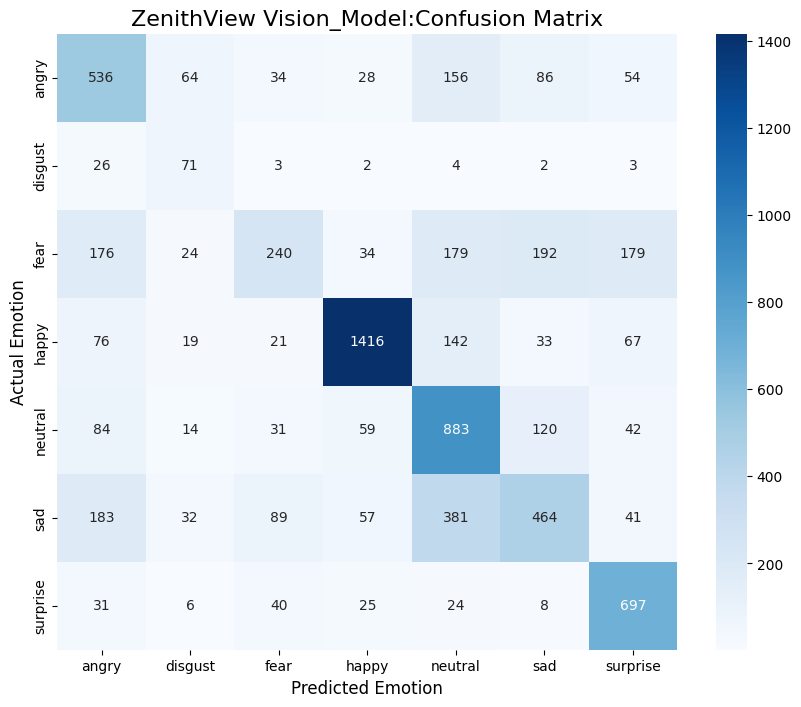

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

model = tf.keras.models.load_model('ZenithView_CustomCNN_Best_17.keras')


test_generator.reset()
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("\n--- ZenithView Classification Report ---")
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

cm = confusion_matrix(y_true, y_pred)


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, 
            yticklabels=class_labels)

plt.title('ZenithView Vision_Model:Confusion Matrix', fontsize=16)
plt.ylabel('Actual Emotion', fontsize=12)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.show()